<a href="https://colab.research.google.com/github/dookda/cmu_py499/blob/main/proj_fai_urban/urban_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
# dataset_path = '/content/drive/MyDrive/_DATASET/sc_pic/scpic_yolo11'
dataset_path = '/content/drive/MyDrive/_DATASET/urban_fai_yolo12'

In [ ]:
# install yolo 11 from ultralytics
!pip install ultralytics

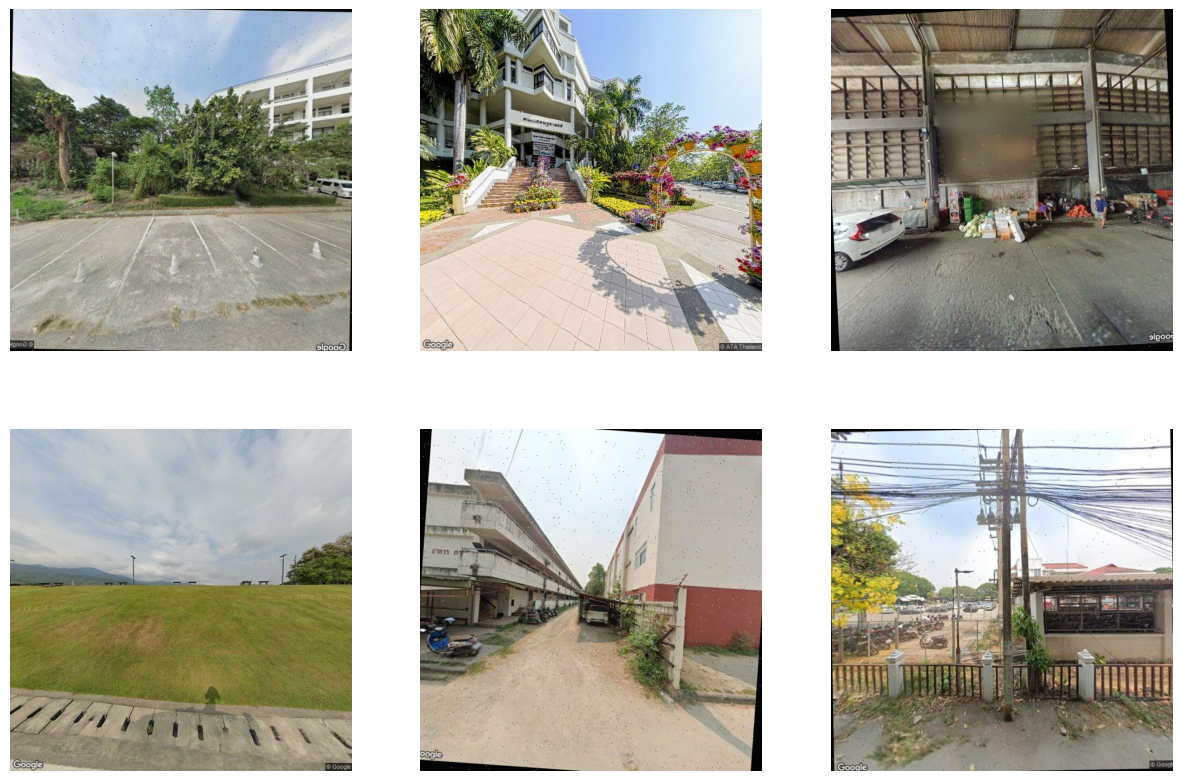

In [34]:
# prompt: show 2-3 image
import os
import random
import cv2
import matplotlib.pyplot as plt

# Select 2-3 random image files
validImagePath = os.path.join(dataset_path, 'train', 'images')
imageFiles = [f for f in os.listdir(validImagePath) if f.endswith('.jpg')]
numImages = min(6, len(imageFiles))
random.shuffle(imageFiles)
selectedImage = imageFiles[:numImages]

# show 2x3 row col
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten()
for i, imageFile in enumerate(selectedImage):
    image = cv2.imread(os.path.join(validImagePath, imageFile))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    axs[i].imshow(image)
    axs[i].axis('off')
plt.show()

In [19]:
# load model
from ultralytics import YOLO
model = YOLO('yolo11m.pt')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


100%|██████████| 38.8M/38.8M [00:00<00:00, 51.6MB/s]


In [35]:
yml_file = os.path.join(dataset_path, 'data.yaml')

In [ ]:
# custom yolo model
result = model.train(
    data=yml_file,
    epochs=50,
    imgsz=640,
    batch=8,
    # optimizer='auto',
    # lr0=0.0001,
    # lrf=0.01,
    # dropout=0.25,
    # device='cpu',
    device=0,
    # seed=42
    name="yolov11-scpic"
)



Ultralytics 8.3.155 🚀 Python-3.11.13 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/_DATASET/urban_fai_yolo12/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11-scpic3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

train: Scanning /content/drive/MyDrive/_DATASET/urban_fai_yolo12/train/labels... 524 images, 180 backgrounds, 0 corrupt: 100%|██████████| 704/704 [05:28<00:00,  2.14it/s]


train: New cache created: /content/drive/MyDrive/_DATASET/urban_fai_yolo12/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.5±0.2 ms, read: 0.1±0.0 MB/s, size: 83.3 KB)


val: Scanning /content/drive/MyDrive/_DATASET/urban_fai_yolo12/valid/labels... 70 images, 0 backgrounds, 0 corrupt: 100%|██████████| 70/70 [01:18<00:00,  1.12s/it]

val: New cache created: /content/drive/MyDrive/_DATASET/urban_fai_yolo12/valid/labels.cache


...


      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      26/50      5.05G      1.838      2.963      2.079         24        640: 100%|██████████| 88/88 [00:29<00:00,  3.00it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 5/5 [00:01<00:00,  4.23it/s]

                   all         70        132      0.126      0.144       0.11     0.0616



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      27/50      5.07G      1.841      2.903      2.054         31        640:  85%|████████▌ | 75/88 [00:25<00:04,  3.20it/s]


image 1/1 /content/drive/MyDrive/_DATASET/sc_pic/scpic_yolo8/test/images/LINE_ALBUM_Betrago-Lab-dimension-dataset_250606_19_jpg.rf.7b0fa731f616a7a105f980ca7c36cbcf.jpg: 640x640 6 circles, 36.9ms
Speed: 2.6ms preprocess, 36.9ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


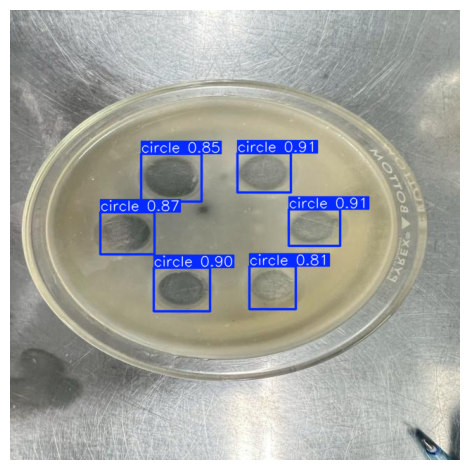

In [32]:
bestModelPath = '/content/runs/detect/yolov11-scpic2/weights/best.pt'
bestModel = YOLO(bestModelPath)

validImagePath = os.path.join(dataset_path, 'test', 'images')
imageFiles = [f for f in os.listdir(validImagePath) if f.endswith('.jpg')]

numImages = len(imageFiles)
selectedImage = [imageFiles[i] for i in range(0, numImages)]

for i in imageFiles:
  imagePath = os.path.join(validImagePath, i)
  results = bestModel.predict(source=imagePath, imgsz=640)
  annotatedImage = results[0].plot()
  annotatedImageRGB = cv2.cvtColor(annotatedImage, cv2.COLOR_BGR2RGB)
  plt.imshow(annotatedImageRGB)
  plt.axis('off')
  plt.tight_layout()
  plt.show()